In [2]:
import json
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
MetaScore_all = {}

def load_metascore(cancer):
    file_path = f"MetaScore_{cancer}.json"
    with open(file_path, 'r', encoding='utf-8') as f:
        MetaScore = json.load(f)
    return MetaScore

MetaScore_all = {
    'ccRCC': load_metascore('ccRCC'),
    'Melanoma': load_metascore('Melanoma'),
    'NSCLC': load_metascore('NSCLC')
}

In [5]:
import pandas as pd

dfs = [pd.DataFrame(MetaScore_all[cancer]) for cancer in cancers]

MetaScore_overall_df = sum(dfs)

MetaScore_overall_dict = MetaScore_overall_df.to_dict()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

COMPONENT_COLORS = {
    'Broad Utility': '#3498db',
    'Narrow Utility': '#9b59b6',
    'Privacy': '#e74c3c'
}


def plot_weighted_composite_scores(
    MetaScore: dict,
    broad_weight: float = 0.3,
    narrow_weight: float = 0.5,
    privacy_weight: float = 0.2,
    figsize: tuple = (10, 7),
    save_path: str = None,
    orientation: str = 'horizontal',
):
    """
    Plot weighted composite scores as stacked bars.
    Assumes MetaScore values are already normalized (0-1 range).
    """
    try:
        plt.style.use(["science", "nature", "notebook"])
    except Exception:
        pass
    
    plt.rcParams.update({
        'text.usetex': False,
        'axes.edgecolor': '#333333',
        'xtick.minor.visible': False,
        'ytick.minor.visible': False,
        'xtick.top': False,
        'ytick.right': False,
    })
    
    df = pd.DataFrame(MetaScore)
    df_final = pd.DataFrame()
    
    # Broad Utility: average of Univariate and Bivariate, weighted
    df_final['Broad Utility'] = (
        (df['UnivariateScore'] + df['BivariateScore']) / 2
    ) * broad_weight
    
    # Narrow Utility: average of 5 narrow metrics, weighted
    narrow_metrics = ['DGE', 'GSEA', 'ssGSEA', 'Cell Deconvolution', 'Survival Analysis']
    df_final['Narrow Utility'] = df[narrow_metrics].mean(axis=1) * narrow_weight
    
    # Privacy: direct weighted score
    df_final['Privacy'] = df['Privacy'] * privacy_weight
    
    # Sort
    df_final['Total'] = df_final.sum(axis=1)
    df_final = df_final.sort_values('Total', ascending=(orientation == 'vertical')).drop(columns='Total')
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    datasets = df_final.index.tolist()
    n_datasets = len(datasets)
    
    if orientation == 'horizontal':
        y = np.arange(n_datasets)
        height = 0.6
        left = np.zeros(n_datasets)
        
        for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
            values = df_final[component].values
            color = COMPONENT_COLORS[component]
            
            bars = ax.barh(y, values, height, left=left, label=component,
                          color=color, edgecolor='white', linewidth=1.5, alpha=0.9)
            
            for i, (bar, val) in enumerate(zip(bars, values)):
                if val > 0.02:  # Show label if segment wide enough
                    ax.text(left[i] + val / 2, bar.get_y() + bar.get_height() / 2,
                           f'{val:.2f}', ha='center', va='center',
                           color='white', fontsize=9, fontweight='bold')
            
            left += values
        
        # Total labels
        for i, total in enumerate(left):
            ax.text(total + 0.02, i, f'{total:.2f}',
                   ha='left', va='center', color='black', fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Rank-derived score', fontsize=12, fontweight='bold')
        ax.set_ylabel('SDG Methods', fontsize=12, fontweight='bold')
        ax.set_yticks(y)
        ax.set_yticklabels([f"$\\mathbf{{{ds}}}$" for ds in datasets], fontsize=11)
        
        for tick_label, dataset in zip(ax.get_yticklabels(), datasets):
            tick_label.set_color(DATASET_COLORS.get(dataset, '#333333'))
        
        ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)
        ax.set_xlim(0, left.max() * 1.15)
        legend_loc = 'upper right'
        
    else:  # vertical
        x = np.arange(n_datasets)
        width = 0.6
        bottom = np.zeros(n_datasets)
        
        for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
            values = df_final[component].values
            color = COMPONENT_COLORS[component]
            
            bars = ax.bar(x, values, width, bottom=bottom, label=component,
                         color=color, edgecolor='white', linewidth=1.5, alpha=0.9)
            
            for i, (bar, val) in enumerate(zip(bars, values)):
                if val > 0.02:
                    ax.text(bar.get_x() + bar.get_width() / 2, bottom[i] + val / 2,
                           f'{val:.2f}', ha='center', va='center',
                           color='white', fontsize=9, fontweight='bold')
            
            bottom += values
        
        # Total labels
        for i, total in enumerate(bottom):
            ax.text(i, total + 0.02, f'{total:.2f}',
                   ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')
        
        ax.set_ylabel('Rank-derived score', fontsize=12, fontweight='bold')
        ax.set_xlabel('SDG methods', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f"$\\mathbf{{{ds}}}$" for ds in datasets],
                          rotation=45, ha='right', fontsize=11)
        
        for tick_label, dataset in zip(ax.get_xticklabels(), datasets):
            tick_label.set_color(DATASET_COLORS.get(dataset, '#333333'))
        
        ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
        ax.set_ylim(0, bottom.max() * 1.1)
        legend_loc = 'upper left'
    
    # ax.set_title('Weighted Composite Score: Broad vs Narrow vs Privacy',
    #             fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc=legend_loc, frameon=True, fontsize=10, fancybox=True, shadow=True)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    
    df_final['Total'] = df_final.sum(axis=1)
    return fig, df_final.sort_values('Total', ascending=True)  # ascending=True vì lower is better

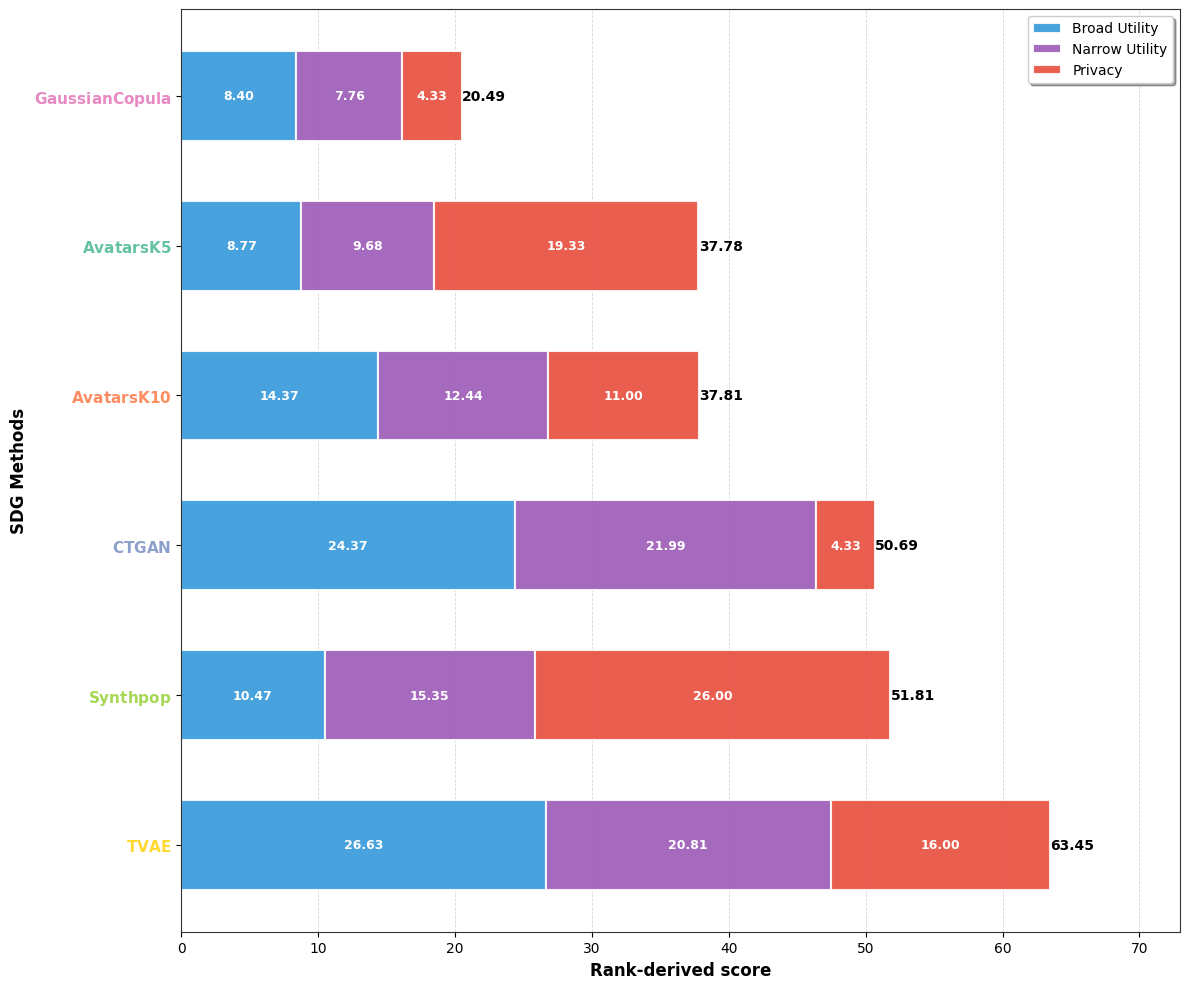

                 Broad Utility  Narrow Utility    Privacy      Total
Gaussian Copula       8.400000        7.760000   4.333333  20.493333
Avatars K5            8.766667        9.680000  19.333333  37.780000
Avatars K10          14.366667       12.440000  11.000000  37.806667
CTGAN                24.366667       21.986667   4.333333  50.686667
Synthpop             10.466667       15.346667  26.000000  51.813333
TVAE                 26.633333       20.813333  16.000000  63.446667


In [20]:
fig, results_df = plot_weighted_composite_scores(
    MetaScore=MetaScore_overall_dict,
    broad_weight=1/3,
    narrow_weight=1/3,
    privacy_weight=1/3,
    figsize=(12, 10),
    orientation='horizontal',
    save_path = 'MetaScore_all.pdf'
)

results_df.to_csv('MetaScore_all.csv', index = True)
print(results_df.to_string())